## Random Forest using EMD (Empirical Mode Decomposition)

In [1]:
%pip install EMD-signal

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mne
import os
import warnings

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from PyEMD import EMD
from scipy.stats import entropy

# Ignore MNE warnings to keep the output clean
warnings.filterwarnings('ignore')


   ---------------------------------------- 0/6 [ppft]
   ---------------------------------------- 0/6 [ppft]
   ---------------------------------------- 0/6 [ppft]
   ---------------------------------------- 0/6 [ppft]
   ---------------------------------------- 0/6 [ppft]
   ---------------------------------------- 0/6 [ppft]
   ------ --------------------------------- 1/6 [pox]
   ------ --------------------------------- 1/6 [pox]
   ------ --------------------------------- 1/6 [pox]
   ------------- -------------------------- 2/6 [dill]
   ------------- -------------------------- 2/6 [dill]
   ------------- -------------------------- 2/6 [dill]
   ------------- -------------------------- 2/6 [dill]
   ------------- -------------------------- 2/6 [dill]
   ------------- -------------------------- 2/6 [dill]
   ------------- -------------------------- 2/6 [dill]
   ------------- -------------------------- 2/6 [dill]
   ------------- -------------------------- 2/6 [dill]
   ---------

In [2]:
%pip install mne-qt-browser PyQt5
mne.viz.set_browser_backend('qt')

Note: you may need to restart the kernel to use updated packages.
Using qt as 2D backend.


In [3]:
df_demo = pd.read_csv('table/Demographics.csv')
df_bpi = pd.read_csv('table/BPI Answers.csv')
df_paindetect = pd.read_csv('table/PainDetect Answers.csv')

# Setting the ID columns to the same type
df_demo['ID'] = df_demo['ID'].astype(str)
df_bpi['ID'] = df_bpi['ID'].astype(str)
df_paindetect['ID'] = df_paindetect['ID'].astype(str)

# Merging the tables by ID
df_complete = pd.merge(df_demo, df_bpi, on='ID', how='inner')
df_complete = pd.merge(df_complete, df_paindetect, on='ID', how='inner')

df_complete = df_complete.dropna(subset=['Actual Pain'])

In [4]:
# Instantiate the EMD model
emd = EMD()

# Define only the most relevant channels
target_channels = ['P7', 'P8', 'C3', 'C4', 'F3', 'F4']
desired_num_imfs = 4 # Extracting 4 IMFs

X_emd_features = []
y_labels_emd = []
feature_names_emd = []

eeg_folder = './cleaned' 

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Graph saved as 'images\EMD_Visualization_Channel_C4.png'!


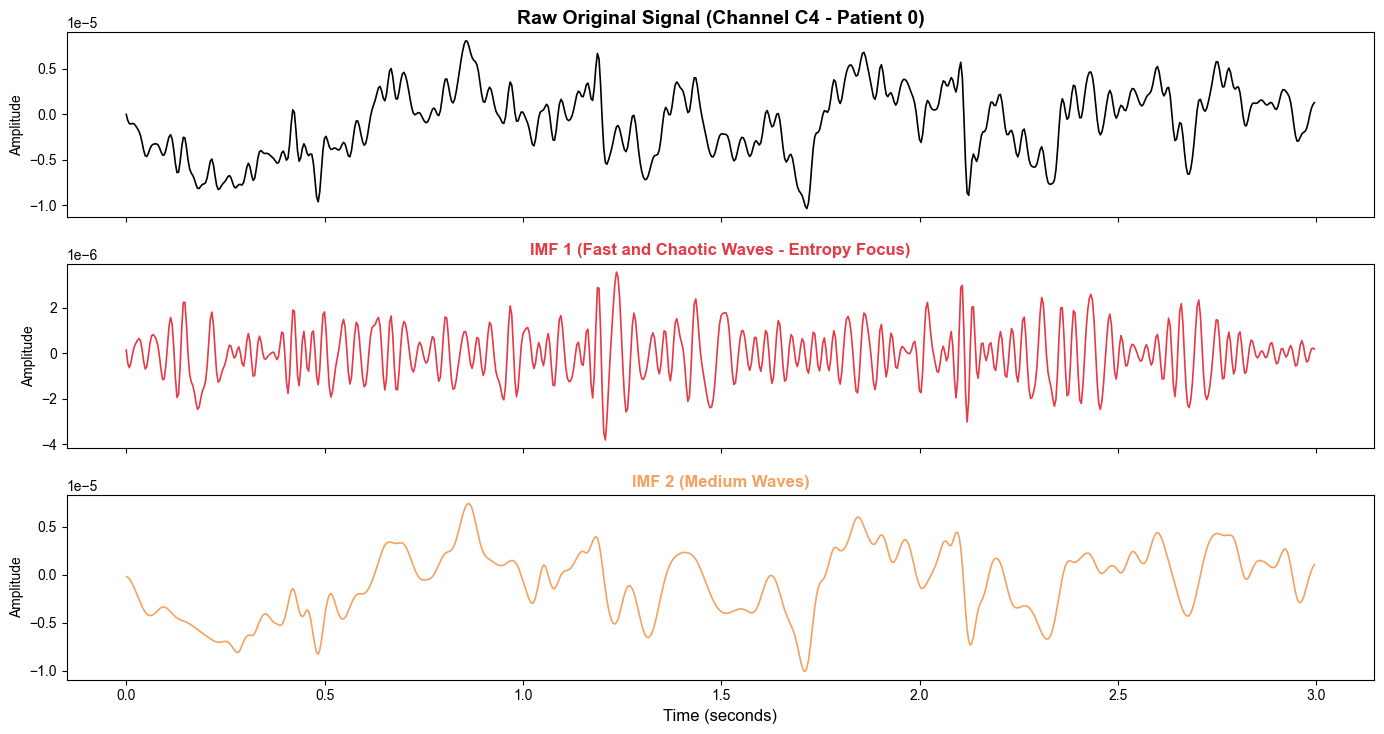

In [5]:
# Choose the first patient from the table and the Gold channel (C4)
patient_id = int(float(df_complete.iloc[0]['ID']))
chosen_channel = 'C4'
path = os.path.join(eeg_folder, f"ID{patient_id}_preproc_eeg.fif")

if os.path.exists(path):
    # Load the EEG
    raw = mne.io.read_raw_fif(path, preload=True, verbose=False)
    raw.pick_channels([chosen_channel])
    
    full_signal = raw.get_data()[0, :] # Gets the 1D signal vector
    full_time = raw.times
    sfreq = raw.info['sfreq']
    
    # Take only a 3-second segment so we can SEE the waves
    samples_3s = int(3 * sfreq) 
    signal_segment = full_signal[:samples_3s]
    time_segment = full_time[:samples_3s]

    # Run EMD only on this segment
    emd = EMD()
    imfs = emd.emd(signal_segment, max_imf=4)

    # Create the visualization
    num_plots = len(imfs) + 1
    fig, axes = plt.subplots(num_plots, 1, figsize=(14, 2.5 * num_plots), sharex=True)
    sns.set_theme(style="whitegrid")

    # Plot 1: Original Signal (The Soup Pot)
    axes[0].plot(time_segment, signal_segment, color='black', linewidth=1.2)
    axes[0].set_title(f"Raw Original Signal (Channel {chosen_channel} - Patient {patient_id})", fontsize=14, fontweight='bold')
    axes[0].set_ylabel("Amplitude")

    # Plots 2 onwards: The IMFs (The Onion Layers)
    colors = ['#e63946', '#f4a261', '#2a9d8f', '#264653', '#8338ec']
    titles = [
        "IMF 1 (Fast and Chaotic Waves - Entropy Focus)",
        "IMF 2 (Medium Waves)",
        "IMF 3 (Slow Waves)",
        "IMF 4 (Very Slow Waves / Residual)"
    ]

    for i, imf in enumerate(imfs):
        imf_title = titles[i] if i < len(titles) else f"IMF {i+1}"
        
        axes[i+1].plot(time_segment, imf, color=colors[i % len(colors)], linewidth=1.2)
        axes[i+1].set_title(imf_title, fontsize=12, fontweight='bold', color=colors[i % len(colors)])
        axes[i+1].set_ylabel("Amplitude")

    axes[-1].set_xlabel("Time (seconds)", fontsize=12)
    plt.tight_layout()
    
    # Create the 'images' folder if it doesn't exist yet
    os.makedirs("images", exist_ok=True)
    
    # Define the save path inside the new folder
    save_path = os.path.join("images", "EMD_Visualization_Channel_C4.png")
    
    # Save the image and show
    plt.savefig(save_path, dpi=300)
    print(f"Graph saved as '{save_path}'!")
    plt.show()

else:
    print(f"Patient {patient_id}'s file not found in the {eeg_folder} folder.")

In [7]:
for index, row in df_complete.iterrows():
    patient_id = int(float(row['ID']))
    pain_score = float(row['Actual Pain'])
    path = os.path.join(eeg_folder, f"ID{patient_id}_preproc_eeg.fif")
    
    if os.path.exists(path):
        try:
            raw = mne.io.read_raw_fif(path, preload=True, verbose=False)
            raw.pick_channels(target_channels) 
            
            data = raw.get_data()
            channel_names = raw.ch_names
            
            patient_features = []
            temp_names = []
            
            # CHANNEL BY CHANNEL LOOP
            for i, channel in enumerate(channel_names):
                channel_signal = data[i, :]
                
                # EMD calculates the IMFs
                imfs = emd.emd(channel_signal, max_imf=desired_num_imfs)
                
                # IMF LOOP WITH SIZE GUARANTEE (PADDING)
                for num_imf in range(desired_num_imfs):
                    
                    # If EMD found this IMF, calculate data normally
                    if num_imf < len(imfs):
                        imf = imfs[num_imf]
                        
                        energy = np.var(imf)
                        counts, _ = np.histogram(imf, bins=20, density=True)
                        probability = counts / np.sum(counts)
                        shannon_entropy = entropy(probability)
                        
                    # If EMD didn't find it, fill with zero to avoid Numpy errors
                    else:
                        energy = 0.0
                        shannon_entropy = 0.0
                        
                    # Adds patient features
                    patient_features.append(energy)
                    patient_features.append(shannon_entropy)
                    
                    if not feature_names_emd:
                        temp_names.append(f"EMD_{channel}_IMF{num_imf+1}_Energy")
                        temp_names.append(f"EMD_{channel}_IMF{num_imf+1}_Entropy")
            
            if not feature_names_emd:
                feature_names_emd = temp_names
                
            X_emd_features.append(patient_features)
            y_labels_emd.append(pain_score)
            print(f"[OK] Patient {patient_id} decomposed with EMD.")
            
        except Exception as e:
            print(f"[ERROR] Patient {patient_id}: {e}")

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
[OK] Patient 0 decomposed with EMD.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
[OK] Patient 1 decomposed with EMD.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
[OK] Patient 2 decomposed with EMD.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
[OK] Patient 3 decomposed with EMD.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
[OK] Patient 4 decomposed with EMD.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
[OK] Patient 5 decomposed with EMD.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
[OK] Patient 6 decomposed with EMD.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
[OK] Patient 7 decomposed with EMD.
NOTE: pick_channels() is a legacy function. New code should use inst.pic

In [8]:
# Transform into NumPy arrays
X_emd = np.array(X_emd_features)
y_emd = np.array(y_labels_emd)

print(f"\nEMD Extraction Completed! Shape: {X_emd.shape} (Patients x EMD Features)")


EMD Extraction Completed! Shape: (36, 48) (Patients x EMD Features)


In [9]:
# Checking if the EMD matrix was successfully created in the previous step
if 'X_emd' in locals() and X_emd.shape[0] > 0:
    print("Evaluating Random Forest model with EMD features...")
    
    # Transform the continuous target into binary (Severe vs Mild/Mod Pain)
    y_class_emd = np.where(y_emd >= 6, 1, 0)
    
    print(f"\nClass distribution:")
    print(f"- Patients with Severe Pain (>=6): {sum(y_class_emd == 1)}")
    print(f"- Patients with Mild/Mod Pain (<6): {sum(y_class_emd == 0)}\n")

    # Selecting the top 5 EMD features to avoid overfitting
    num_features_to_select = 5 
    
    # Creating the Pipeline (Standardization -> Selection -> Random Forest)
    pipeline_emd = Pipeline([
        ('scaler', StandardScaler()),
        ('selector', SelectKBest(score_func=f_classif, k=num_features_to_select)), 
        ('rf', RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42))
    ])
    
    # Stratified K-Fold Cross-Validation (5 splits)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # Calculating performance metrics
    scores_acc = cross_val_score(pipeline_emd, X_emd, y_class_emd, cv=skf, scoring='accuracy')
    scores_auc = cross_val_score(pipeline_emd, X_emd, y_class_emd, cv=skf, scoring='roc_auc')
    
    print("CLASSIFICATION MODEL PERFORMANCE (EMD)")
    print(f"Average Accuracy: {scores_acc.mean()*100:.1f}% (Std dev: {scores_acc.std()*100:.1f}%)")
    print(f"Average AUC-ROC: {scores_auc.mean():.3f}")
    
    pipeline_emd.fit(X_emd, y_class_emd)
    
    selector = pipeline_emd.named_steps['selector']
    mask = selector.get_support()
    final_biomarkers = np.array(feature_names_emd)[mask]
    importances = pipeline_emd.named_steps['rf'].feature_importances_
    
    print(f"\nTOP {num_features_to_select} EMD BIOMARKERS (CLASSIFICATION)")
    for bio, imp in zip(final_biomarkers, importances):
        print(f"- {bio}: {imp*100:.1f}% importance")

else:
    print("The X_emd matrix was not found. Run the EMD extraction cell first!")

Evaluating Random Forest model with EMD features...

Class distribution:
- Patients with Severe Pain (>=6): 19
- Patients with Mild/Mod Pain (<6): 17

CLASSIFICATION MODEL PERFORMANCE (EMD)
Average Accuracy: 61.1% (Std dev: 10.6%)
Average AUC-ROC: 0.583

TOP 5 EMD BIOMARKERS (CLASSIFICATION)
- EMD_P8_IMF2_Energy: 37.5% importance
- EMD_P8_IMF4_Energy: 7.5% importance
- EMD_C4_IMF1_Entropy: 42.6% importance
- EMD_C4_IMF4_Energy: 6.6% importance
- EMD_C4_IMF4_Entropy: 5.9% importance
